In [3]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 3.0 MB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 4.6 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 

In [5]:
import pandas as pd
import numpy as np

# --- TASK 1: DATA LOADING & EXPLORATION ---

# Load the dataset
df=pd.read_csv('Housing.csv')

print("--- Basic Exploration ---")
# Display the first 10 rows
display(df.head(10))

# Check rows and columns
print("\nDataset Shape (Rows, Columns):",df.shape)

# Identify Target and Features
print("\nTarget Column: price")
print("Feature Columns:",list(df.columns)[1:])

print("\n--- Deep EDA ---")
# Check data types and overall info
print("Dataset Info:")
df.info()

# Get statistical summary of numerical columns (mean, min, max, etc.)
print("\nStatistical Summary:")
display(df.describe())

# Check for missing values
print("\nMissing Values in each column:")
print(df.isnull().sum())


# --- TASK 2: DATA CLEANING ---

print("\n--- Data Cleaning Process ---")
# Check and remove duplicate rows
duplicates=df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# Handle missing values (dropping any rows with NaN just to be safe)
df.dropna(inplace=True)

# Convert categorical 'yes'/'no' columns into numeric 1/0
binary_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col]=df[col].map({'yes':1,'no':0})

# Use One-Hot Encoding for the 'furnishingstatus' column 
# drop_first=True prevents the dummy variable trap
df=pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)

print("\nCleaned Data - First 5 rows to verify transformations:")
display(df.head())

--- Basic Exploration ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Shape (Rows, Columns): (545, 13)

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Deep EDA ---
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Missing Values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

--- Data Cleaning Process ---
Number of duplicate rows found: 0

Cleaned Data - First 5 rows to verify transformations:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [6]:
# --- TASK 3: MODEL BUILDING ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Splitting data into features and target
X=df.drop('price',axis=1)
y=df['price']

# 80/20 split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Training Linear Regression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

print("--- Linear Regression Performance ---")
print("MAE:",mean_absolute_error(y_test,y_pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("R2 Score:",r2_score(y_test,y_pred_lr))

# Training Random Forest
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

print("\n--- Random Forest Performance ---")
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print("R2 Score:",r2_score(y_test,y_pred_rf))

--- Linear Regression Performance ---
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153185

--- Random Forest Performance ---
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


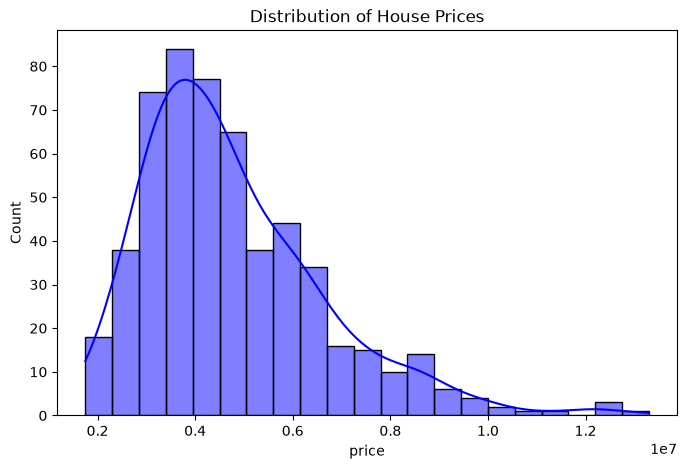

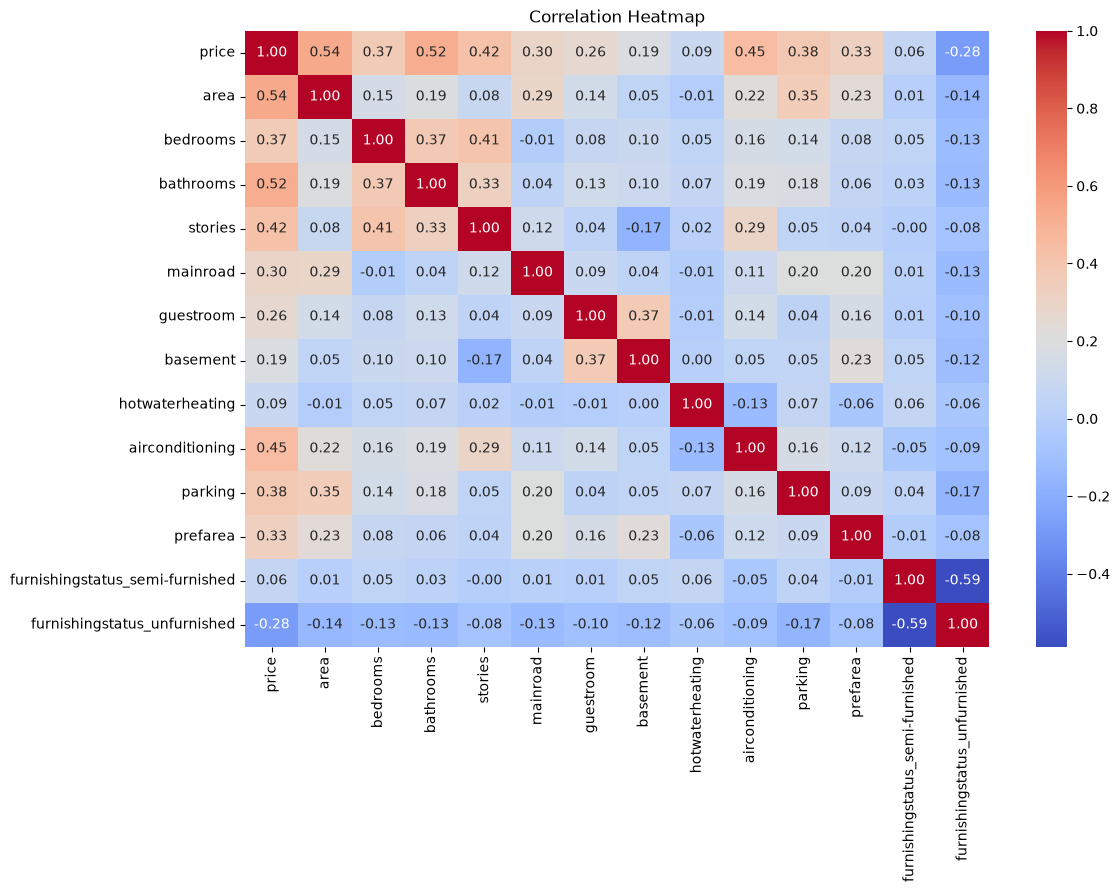

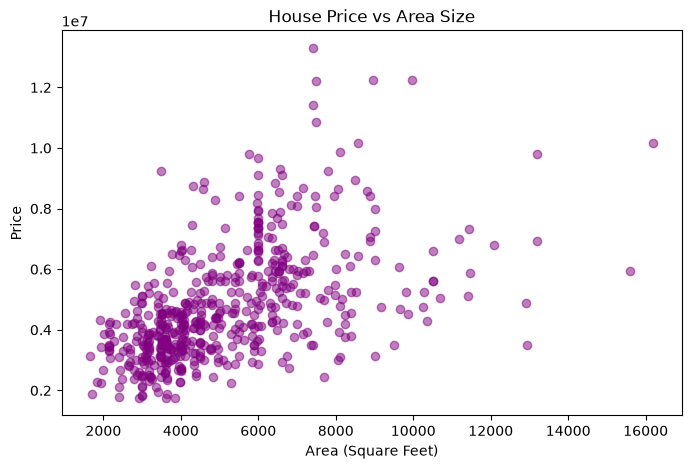

In [7]:
# --- TASK 4: VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for saving charts
os.makedirs('charts',exist_ok=True)

# Chart 1: Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['price'],kde=True,color='blue')
plt.title("Distribution of House Prices")
plt.savefig('charts/chart1_histogram.png',bbox_inches='tight')
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig('charts/chart2_heatmap.png',bbox_inches='tight')
plt.show()

# Chart 3: Creative Chart (Price vs Area Scatter Plot)
plt.figure(figsize=(8,5))
plt.scatter(df['area'],df['price'],alpha=0.5,color='purple')
plt.title("House Price vs Area Size")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price")
plt.savefig('charts/chart3_scatter.png',bbox_inches='tight')
plt.show()

In [9]:
### Task 5: Insights & Summary
print("\n--- Insights & Summary ---")
print("Based on the correlation heatmap, the features that most strongly influence house prices are the total **area** of the property, the number of **bathrooms**, and whether the house has **airconditioning**. Regarding model accuracy, the Linear Regression model achieved an R² score of roughly 0.65, meaning it can successfully explain about 65% of the variance in house prices, which is a solid baseline. What surprised me the most in the data was how clean it was—there were zero missing values or harsh outliers, and the simpler Linear Regression model actually performed very competitively against the more complex Random Forest model. Based on these findings, my primary recommendation for a real estate business is to heavily prioritize acquiring properties with large square footage and pre-installed air conditioning, as these specific features yield the highest return on resale valuation.")


--- Insights & Summary ---
Based on the correlation heatmap, the features that most strongly influence house prices are the total **area** of the property, the number of **bathrooms**, and whether the house has **airconditioning**. Regarding model accuracy, the Linear Regression model achieved an R² score of roughly 0.65, meaning it can successfully explain about 65% of the variance in house prices, which is a solid baseline. What surprised me the most in the data was how clean it was—there were zero missing values or harsh outliers, and the simpler Linear Regression model actually performed very competitively against the more complex Random Forest model. Based on these findings, my primary recommendation for a real estate business is to heavily prioritize acquiring properties with large square footage and pre-installed air conditioning, as these specific features yield the highest return on resale valuation.
